In [56]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
#리뷰 파일 불러오기
import pandas as pd

review_file = '/content/drive/MyDrive/review_table/user-item_table.csv'
df = pd.read_csv(review_file, encoding='utf-8-sig')

df.tail()

,user,name_product,total_score
14686,psrla****,힌스_무드인핸서워터리퀴드글로우_하모니어스,4.0
14687,빵먹고싶은사람,힌스_무드인핸서워터리퀴드글로우_하모니어스,4.0
14688,totoro,힌스_무드인핸서워터리퀴드글로우_하모니어스,4.0
14689,브리즈가되,힌스_무드인핸서워터리퀴드글로우_하모니어스,5.0
14690,totoro,힌스_무드인핸서워터리퀴드글로우_하모니어스,4.0


In [58]:
#리뷰파일로 matrix 만들기
user_item_matrix = df.pivot_table(index='user', columns='name_product', values='total_score', fill_value=0)
print(user_item_matrix)

name_product    네이처리퍼블릭_허니멜팅립_고소한코코넛    네이처리퍼블릭_허니멜팅립_무드플럼핑  \
user                                                          
 olyoonzl                        0.0                    0.0   
00****                           0.0                    0.0   
00000000                         0.0                    0.0   
0010000                          0.0                    0.0   
005****                          0.0                    0.0   
...                              ...                    ...   
히히히잉11                           0.0                    0.0   
힌동이                              0.0                    0.0   
힌트걸                              0.0                    0.0   
힝구르르르                            0.0                    0.0   
힝힁헹헝홍                            0.0                    0.0   

name_product    네이처리퍼블릭_허니멜팅립_무화과한스푼    네이처리퍼블릭_허니멜팅립_블랙체리슈  \
user                                                          
 olyoonzl                        0.0                  

In [59]:
# 사용자별 평균 정규화
user_means = user_item_matrix.mean(axis=1)
mean_normalized_matrix = user_item_matrix.sub(user_means, axis=0)

print("사용자별 평균 정규화 결과:")
print(mean_normalized_matrix)

# 파일로 저장
#mean_normalized_matrix_file = "mean_normalized_matrix.csv"
#mean_normalized_matrix.to_csv(mean_normalized_matrix_file, index=True)

사용자별 평균 정규화 결과:
name_product    네이처리퍼블릭_허니멜팅립_고소한코코넛    네이처리퍼블릭_허니멜팅립_무드플럼핑  \
user                                                          
 olyoonzl                  -0.004065              -0.004065   
00****                     -0.005081              -0.005081   
00000000                   -0.005081              -0.005081   
0010000                    -0.005081              -0.005081   
005****                    -0.005081              -0.005081   
...                              ...                    ...   
히히히잉11                     -0.005081              -0.005081   
힌동이                        -0.010163              -0.010163   
힌트걸                        -0.005081              -0.005081   
힝구르르르                      -0.005081              -0.005081   
힝힁헹헝홍                      -0.005081              -0.005081   

name_product    네이처리퍼블릭_허니멜팅립_무화과한스푼    네이처리퍼블릭_허니멜팅립_블랙체리슈  \
user                                                          
 olyoonzl                  -0.004065  

In [60]:
import numpy as np

# 사용자-아이템 매트릭스
matrix = user_item_matrix.values  #(Pandas DataFrame → NumPy 배열)
num_users, num_items = matrix.shape

# Matrix Factorization 설정
k = 20  # 잠재 요인 수, 사용자와 아이템의 관계를 설명할 숨은 요인의 개수
alpha = 0.01  # 학습률
beta = 0.02  # 정규화 항
iterations = 500  # 반복 횟수

# P, Q 행렬 초기화 (임의의 값으로 시작)
P = np.random.rand(num_users, k)
Q = np.random.rand(num_items, k)

# 평점 있는 항목의 위치 확인
non_zero_indices = np.argwhere(matrix > 0)

# SGD 학습
for step in range(iterations):
    for user, item in non_zero_indices:
        rating = matrix[user, item]

        # 예측 평점
        prediction = np.dot(P[user, :], Q[item, :])
        error = rating - prediction  # 예측 오차

        # SGD 업데이트
        P[user, :] += alpha * (error * Q[item, :] - beta * P[user, :])
        Q[item, :] += alpha * (error * P[user, :] - beta * Q[item, :])

    # 손실 계산 (옵션)
    loss = sum(
        (matrix[user, item] - np.dot(P[user, :], Q[item, :])) ** 2
        for user, item in non_zero_indices
    )
    loss += beta * (np.sum(np.square(P)) + np.sum(np.square(Q)))  # 정규화 항
    if step % 500 == 0:  # 500번마다 손실 출력
        print(f"Iteration {step}, Loss: {loss}")

# 최종 예측 매트릭스
predicted_ratings = np.dot(P, Q.T)

# 다시 DataFrame으로 변환
predicted_ratings_df = pd.DataFrame(predicted_ratings, index=user_item_matrix.index, columns=user_item_matrix.columns)

print("\nMatrix Factorization 결과 예측 평점:")
print(predicted_ratings_df)

Iteration 0, Loss: 11011.555625594669

Matrix Factorization 결과 예측 평점:
name_product    네이처리퍼블릭_허니멜팅립_고소한코코넛    네이처리퍼블릭_허니멜팅립_무드플럼핑  \
user                                                          
 olyoonzl                   4.083127               4.213000   
00****                      5.377577               4.949660   
00000000                    4.962792               5.026179   
0010000                     5.096272               4.959244   
005****                     5.124289               5.266292   
...                              ...                    ...   
히히히잉11                      4.462531               4.887207   
힌동이                         4.379338               4.744777   
힌트걸                         4.395944               4.641568   
힝구르르르                       4.673416               4.899025   
힝힁헹헝홍                       4.616065               4.542777   

name_product    네이처리퍼블릭_허니멜팅립_무화과한스푼    네이처리퍼블릭_허니멜팅립_블랙체리슈  \
user                                           

In [ ]:
# RMSE 계산 함수
def calculate_rmse(matrix, predicted_ratings_df, non_zero_indices):
    error = 0
    count = 0
    final_ratings = predicted_ratings_df.values  # 데이터프레임을 넘파이 배열로 변환
    for user, item in non_zero_indices:
        error += (matrix[user, item] - final_ratings[user, item]) ** 2
        count += 1
    return np.sqrt(error / count)

# RMSE 계산
rmse = calculate_rmse(matrix, predicted_ratings_df, non_zero_indices)
print(f"RMSE: {rmse:.4f}")

RMSE: 0.0337


In [ ]:
# 기존 매트릭스에서 빈 값(0인 곳)을 예측된 점수로 채우기
predicted_ratings = np.clip(predicted_ratings, 0, 5)
final_ratings = matrix.copy()  # 기존 매트릭스 복사
final_ratings[matrix == 0] = predicted_ratings[matrix == 0]  # 0인 값에 예측된 점수 채우기

# 다시 DataFrame으로 변환
final_ratings_df = pd.DataFrame(final_ratings, index=user_item_matrix.index, columns=user_item_matrix.columns)

# 최종 결과를 CSV로 저장 (선택사항)
final_ratings_df.to_csv('final_ratings.csv', index=True)

print("\nMatrix Factorization 결과 예측 평점 (빈 값만 채운 최종 결과):")
print(final_ratings_df)


Matrix Factorization 결과 예측 평점 (빈 값만 채운 최종 결과):
name_product    네이처리퍼블릭_허니멜팅립_고소한코코넛    네이처리퍼블릭_허니멜팅립_무드플럼핑  \
user                                                          
 olyoonzl                   4.255176               4.319304   
00****                      5.000000               5.000000   
00000000                    4.941347               5.000000   
0010000                     5.000000               5.000000   
005****                     4.689789               4.686394   
...                              ...                    ...   
히히히잉11                      4.489188               4.521212   
힌동이                         4.344611               4.470163   
힌트걸                         4.299874               4.344036   
힝구르르르                       4.455287               4.391596   
힝힁헹헝홍                       4.355578               4.337859   

name_product    네이처리퍼블릭_허니멜팅립_무화과한스푼    네이처리퍼블릭_허니멜팅립_블랙체리슈  \
user                                                          
 olyoo

In [231]:
user_data_list = []

def get_user_input():
    user_data = {}

    # 1. 사용 중인 색상
    user_data["user_color"] = input("현재 사용하고 있는 색상은 무엇인가요? \n브랜드_제품명_색상으로 입력해주세요: ")

    # 2. 수분감 여부
    hydration_options = ["촉촉", "매트", "상관없음"]
    print(f"원하는 립 제형이 있으신가요? ({', '.join(hydration_options)}):")
    while True:
        hydration = input(">>> ")
        if hydration in hydration_options:
            user_data["hydration_preference"] = hydration
            break
        print("올바른 옵션을 선택해주세요!")

    # 3. 적색 202호
    longevity_options = ["네","아니오", "상관없음"]
    print(f"적색 202호가 포함되지 않은 제품을 추천해드릴까요? ({', '.join(longevity_options)}):")
    while True:
         longevity = input(">>> ")
         if longevity in longevity_options:
             user_data["longevity_preference"] = longevity
             break
         print("올바른 옵션을 선택해주세요!")

    return user_data

if __name__ == "__main__":
    # 사용자 정보 입력
    user = get_user_input()
    user_data_list.append(user)

    print("\n입력한 사용자 정보가 저장되었습니다:")
    print(user_data_list)

현재 사용하고 있는 색상은 무엇인가요? 
브랜드_제품명_색상으로 입력해주세요: 3CE_드롭글로우젤_RAWAPPLE
원하는 립 제형이 있으신가요? (촉촉, 매트, 상관없음):
>>> 촉촉
적색 202호가 포함되지 않은 제품을 추천해드릴까요? (네, 아니오, 상관없음):
>>> 네

입력한 사용자 정보가 저장되었습니다:
[{'user_color': '3CE_드롭글로우젤_RAWAPPLE', 'hydration_preference': '촉촉', 'longevity_preference': '네'}]


In [232]:
def find_matching_products_and_users(user_data_list, final_ratings_df):
    user_color = user_data_list[0]["user_color"]

    print(f"찾고자 하는 색상: {user_color}")

    # 'user_color'와 일치하는 제품 찾기 (열 이름에서 매칭)
    matching_products = [col for col in final_ratings_df.columns if user_color in col]

    if not matching_products:
        print(f"일치하는 제품을 찾을 수 없습니다: {user_color}")
        return

    # 각 매칭된 제품에 대해, 예측된 평점이 4.0 이상인 사용자 찾기
    for product in matching_products:
        print(f"\n'{product}' 제품에 대한 4.0 이상 예측된 사용자:")

        # 해당 제품에 대한 예측 평점
        product_ratings = final_ratings_df[product]

        # 4.0 이상 예측된 사용자 찾기
        high_rated_users = product_ratings[product_ratings >= 4.0].index.tolist()

        if high_rated_users:
            print(f"예측 평점이 4.0 이상인 사용자: {high_rated_users}")
            print(f"총 사용자 수: {len(high_rated_users)}명")  # 사용자 수 출력
        else:
            print("예측 평점이 4.0 이상인 사용자가 없습니다.")

# 예시로 user_data_list에 사용자 데이터가 저장되어 있다고 가정하고,
# 이미 입력된 데이터를 사용해 4.0 이상 예측 평점 사용자 수를 찾기
if __name__ == "__main__":
    # user_data_list에 저장된 마지막 사용자 정보에서 'user_color'를 가져와서 해당 제품 찾기
    find_matching_products_and_users(user_data_list, final_ratings_df)


찾고자 하는 색상: 3CE_드롭글로우젤_RAWAPPLE

'3CE_드롭글로우젤_RAWAPPLE' 제품에 대한 4.0 이상 예측된 사용자:
예측 평점이 4.0 이상인 사용자: [' olyoonzl', '00****', '00000000', '0010000', '005****', '00600', '00나를보면행운가득00', '0105****', '010800****', '0118c****', '012345678', '0123als****', '017****', '030****', '0326', '0517y****', '060****', '0607****', '0612****', '062741', '0704c****', '0802****', '0909****', '090뀨', '0917h****', '0lyoung', '0nll', '0o****', '0su****', '0ㅅ0', '0ㅇ2', '0당근당근0', '0쿨쿨따0', '0힛0', '10****', '10000', '100010010', '1004유영', '100yuj****', '1010', '103848', '1047', '10982', '11037', '112233****', '120', '1201****', '1215d****', '122****', '12PM', '12g****', '12m****', '12rlawl****', '16enchant', '17아', '199****', '1c****', '1eofsh****', '1h0****', '1tym****', '1woo', '1yo2y****', '1일1팩', '2021dc6****', '2221', '277', '28209', '29292', '29reum', '2BBUJIAE', '2bcyj2', '2ezeun', '2ino', '2s2', '2song****', '2년차올영알바생', '2또리야', '2서', '2시15분', '2잰이', '2제2', '3070****', '31****', '3355', '39472', '3K', '43674

In [233]:
def get_reviews_from_high_rated_users(final_ratings_df, user_item_matrix):
    # 예측 평점이 4.0 이상인 사용자 찾기
    high_rated_users = final_ratings_df[final_ratings_df >= 4.0].stack().index.get_level_values(0).unique()

    if len(high_rated_users) == 0:
        print("4.0 이상 예측된 평점을 가진 사용자가 없습니다.")
        return

    print(f"4.0 이상 예측 평점을 가진 사용자: {high_rated_users}")

    # 해당 사용자가 평가한 모든 리뷰를 찾기
    for user in high_rated_users:
        print(f"\n{user}님의 리뷰:")

        # 예측 평점이 4.0 이상인 사용자에 대해 평가한 모든 제품과 평점 출력
        user_reviews = final_ratings_df.loc[user]
        high_rated_reviews = user_reviews[user_reviews >= 4.0]

        if not high_rated_reviews.empty:
            print(f"4.0 이상으로 평가한 제품들:\n{high_rated_reviews}")
        else:
            print(f"4.0 이상으로 평가한 제품이 없습니다.")

# 예시로 final_ratings_df와 user_item_matrix를 사용하여 4.0 이상 예측 평점 사용자들의 리뷰 출력
if __name__ == "__main__":
    get_reviews_from_high_rated_users(final_ratings_df, user_item_matrix)


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  네이처리퍼블릭_허니멜팅립_무드플럼핑     4.272020
  네이처리퍼블릭_허니멜팅립_무화과한스푼    4.559962
  네이처리퍼블릭_허니멜팅립_블랙체리슈     5.000000
  네이처리퍼블릭_허니멜팅립_살구가득      4.547682
                            ...   
힌스_로글로우젤틴트_로프리콧           4.355302
힌스_로글로우젤틴트_베어             4.626343
힌스_로글로우젤틴트_칠              4.814517
힌스_로글로우젤틴트_피버             4.654075
힌스_로글로우젤틴트_히비스커스          4.659715
Name: 한다몽, Length: 952, dtype: float64

한뜍빼기님의 리뷰:
4.0 이상으로 평가한 제품들:
name_product
데이지크_쥬시듀이틴트_칠리셔벗    4.163851
Name: 한뜍빼기, dtype: float64

한라봉요거트님의 리뷰:
4.0 이상으로 평가한 제품들:
name_product
  네이처리퍼블릭_허니멜팅립_고소한코코넛    4.068421
  네이처리퍼블릭_허니멜팅립_무화과한스푼    4.411977
  네이처리퍼블릭_허니멜팅립_블랙체리슈     4.445024
  네이처리퍼블릭_허니멜팅립_살구가득      4.468206
  네이처리퍼블릭_허니멜팅립_상큼달콤리치    4.259895
                            ...   
힌스_로글로우젤틴트_로프리콧           4.158030
힌스_로글로우젤틴트_베어             4.029343
힌스_로글로우젤틴트_칠              4.527096
힌스_로글로우젤틴트_피버             4.610655
힌스_로글로우젤틴트_히비스커스          4.727682
Name: 한라봉요거트, Length: 827, dtype: float64

한라뽕

In [234]:
def get_high_rated_products(final_ratings_df):
    # 예측 평점이 4.0 이상인 사용자들이 평가한 제품을 중복 없이 가져오기
    high_rated_products = set()  # 중복 제거를 위해 set 사용

    # 4.0 이상 평점을 받은 사용자 찾기
    for user in final_ratings_df.index:
        # 사용자가 평가한 제품에 대해서 4.0 이상 평점을 받은 제품만 추출
        high_rated_reviews = final_ratings_df.loc[user]
        high_rated_products.update(high_rated_reviews[high_rated_reviews >= 4.0].index)

    # 결과 출력 (오름차순 정렬)
    print(f"4.0 이상 예측 평점을 받은 제품들 (오름차순):")
    for product in sorted(high_rated_products):
        print(product)

# 예시로 final_ratings_df를 사용하여 4.0 이상 예측 평점이 받은 제품들 출력
if __name__ == "__main__":
    get_high_rated_products(final_ratings_df)


4.0 이상 예측 평점을 받은 제품들 (오름차순):
  네이처리퍼블릭_허니멜팅립_고소한코코넛
  네이처리퍼블릭_허니멜팅립_무드플럼핑
  네이처리퍼블릭_허니멜팅립_무화과한스푼
  네이처리퍼블릭_허니멜팅립_블랙체리슈
  네이처리퍼블릭_허니멜팅립_살구가득
  네이처리퍼블릭_허니멜팅립_상큼달콤리치
  네이처리퍼블릭_허니멜팅립_석류듬뿍
  네이처리퍼블릭_허니멜팅립_여리베리
  네이처리퍼블릭_허니멜팅립_쫀득복숭아
  네이처리퍼블릭_허니멜팅립_탱글포도
 3CE_드롭글로우젤_ESSENTIAL
 네이처리퍼블릭_허니멜팅립_잘익은자두
 네이처리퍼블릭_허니멜팅립_틴트플럼핑
3CE_드롭글로우젤_CALMING
3CE_드롭글로우젤_ESSENTIAL
3CE_드롭글로우젤_MILDER
3CE_드롭글로우젤_NEAT
3CE_드롭글로우젤_RAWAPPLE
3CE_드롭글로우젤_SHY
3CE_드롭글로우젤_VERYSURE
3CE_드롭글로우젤_WEEKEND
3CE_드롭글로우젤_WONDER
3CE_드롭글로우젤_YOUTH
3CE_벨벳립틴트_BITTERHOUR
3CE_벨벳립틴트_BestEVER
3CE_벨벳립틴트_CASHMERENUDE
3CE_벨벳립틴트_CHEEKYROSE
3CE_벨벳립틴트_CHILDLIKE
3CE_벨벳립틴트_COZYCRUSH
3CE_벨벳립틴트_DAFFODIL
3CE_벨벳립틴트_DEFINITION
3CE_벨벳립틴트_FADEIN
3CE_벨벳립틴트_GOINGRIGHT
3CE_벨벳립틴트_LIKEGENTLE
3CE_벨벳립틴트_NEARANDDEAR
3CE_벨벳립틴트_NEWNUDE
3CE_벨벳립틴트_PINKBREAK
3CE_벨벳립틴트_PRIVATE
3CE_벨벳립틴트_SAVEME
3CE_벨벳립틴트_SLOWMOTION
3CE_벨벳립틴트_SPEAKUP
3CE_벨벳립틴트_TAUPE
3CE_벨벳립틴트_THINKAGAIN
3CE_벨벳립틴트_WALKNTALK
3CE_블러매트립스틱_APRICOT
3CE_블러매트립스틱_APRICOTFILTER
3CE_블러매트립스틱_BEEZYMELODY
3CE_블러매트립스틱_INTHEFOG


In [235]:
import pandas as pd

csv_file = '/content/drive/MyDrive/전처리데이터/review.csv'
df1 = pd.read_csv(csv_file, encoding='utf-8-sig')

df1.tail()

,user,name_product,total_score,pigmentation,longevity,application,hydration
14696,psrla****,힌스_무드인핸서워터리퀴드글로우_하모니어스,4.0,3.0,2.0,3.0,3.0
14697,빵먹고싶은사람,힌스_무드인핸서워터리퀴드글로우_하모니어스,4.0,2.0,2.0,3.0,3.0
14698,totoro,힌스_무드인핸서워터리퀴드글로우_하모니어스,4.0,3.0,1.0,3.0,3.0
14699,브리즈가되,힌스_무드인핸서워터리퀴드글로우_하모니어스,5.0,3.0,3.0,3.0,3.0
14700,totoro,힌스_무드인핸서워터리퀴드글로우_하모니어스,4.0,3.0,1.0,2.0,2.0


In [236]:
df11 = df1[['name_product', 'hydration']]
df11= df11.drop(index=3627)

df11.tail()

,name_product,hydration
14696,힌스_무드인핸서워터리퀴드글로우_하모니어스,3.0
14697,힌스_무드인핸서워터리퀴드글로우_하모니어스,3.0
14698,힌스_무드인핸서워터리퀴드글로우_하모니어스,3.0
14699,힌스_무드인핸서워터리퀴드글로우_하모니어스,3.0
14700,힌스_무드인핸서워터리퀴드글로우_하모니어스,2.0


In [237]:
# 'name_product'별로 'hydration'의 평균 계산
df_avg = df11.groupby('name_product')[['hydration']].mean().reset_index()

# 결과를 새로운 파일로 저장
output_file = '/content/drive/MyDrive/전처리데이터/average_hydration.csv'
df_avg.to_csv(output_file, index=False, encoding='utf-8-sig')

df_avg.tail()

,name_product,hydration
967,힌스_로글로우젤틴트_로프리콧,2.75
968,힌스_로글로우젤틴트_베어,2.75
969,힌스_로글로우젤틴트_칠,2.90
970,힌스_로글로우젤틴트_피버,2.60
971,힌스_로글로우젤틴트_히비스커스,2.70


In [238]:
def filter_products_by_hydration(final_ratings_df, user_data_list):
    # 필터링된 제품을 담을 리스트 초기화
    filtered_products = set()  # 중복을 피하기 위해 set 사용

    # user_data_list에 있는 각 사용자의 수분감 선호도에 맞춰 필터링
    for user_data in user_data_list:
        # 사용자 수분감 선호도 가져오기
        hydration_preference = user_data.get("hydration_preference")

        if hydration_preference is None:
            continue  # 수분감 선호도가 없는 경우는 스킵

        # 4.0 이상으로 평가된 제품을 필터링
        for user in final_ratings_df.index:
            user_reviews = final_ratings_df.loc[user]

            if hydration_preference == "촉촉":
                high_hydration_reviews = user_reviews[user_reviews >= 2.5]
                filtered_products.update(high_hydration_reviews.index)

            elif hydration_preference == "매트":
                low_hydration_reviews = user_reviews[user_reviews <= 1.7]
                filtered_products.update(low_hydration_reviews.index)

            elif hydration_preference == "상관없음":
                filtered_products.update(user_reviews.index)

    # 필터링된 제품들 출력 (오름차순으로 정렬)
    print(f"\n{hydration_preference}으로 필터링된 제품들 (오름차순):")
    for product in sorted(filtered_products):
        print(product)


# 예시로 user_data_list를 사용하여 필터링된 제품 출력
def filter_products_based_on_user_data(user_data_list, final_ratings_df):
    # 수분감 선호도에 맞춰 필터링된 제품 출력
    filter_products_by_hydration(final_ratings_df, user_data_list)

if __name__ == "__main__":
    # 예시로 user_data_list와 final_ratings_df를 사용하여 필터링된 제품 출력
    filter_products_based_on_user_data(user_data_list, final_ratings_df)





촉촉으로 필터링된 제품들 (오름차순):
  네이처리퍼블릭_허니멜팅립_고소한코코넛
  네이처리퍼블릭_허니멜팅립_무드플럼핑
  네이처리퍼블릭_허니멜팅립_무화과한스푼
  네이처리퍼블릭_허니멜팅립_블랙체리슈
  네이처리퍼블릭_허니멜팅립_살구가득
  네이처리퍼블릭_허니멜팅립_상큼달콤리치
  네이처리퍼블릭_허니멜팅립_석류듬뿍
  네이처리퍼블릭_허니멜팅립_여리베리
  네이처리퍼블릭_허니멜팅립_쫀득복숭아
  네이처리퍼블릭_허니멜팅립_탱글포도
 3CE_드롭글로우젤_ESSENTIAL
 네이처리퍼블릭_허니멜팅립_잘익은자두
 네이처리퍼블릭_허니멜팅립_틴트플럼핑
3CE_드롭글로우젤_CALMING
3CE_드롭글로우젤_ESSENTIAL
3CE_드롭글로우젤_MILDER
3CE_드롭글로우젤_NEAT
3CE_드롭글로우젤_RAWAPPLE
3CE_드롭글로우젤_SHY
3CE_드롭글로우젤_VERYSURE
3CE_드롭글로우젤_WEEKEND
3CE_드롭글로우젤_WONDER
3CE_드롭글로우젤_YOUTH
3CE_벨벳립틴트_BITTERHOUR
3CE_벨벳립틴트_BestEVER
3CE_벨벳립틴트_CASHMERENUDE
3CE_벨벳립틴트_CHEEKYROSE
3CE_벨벳립틴트_CHILDLIKE
3CE_벨벳립틴트_COZYCRUSH
3CE_벨벳립틴트_DAFFODIL
3CE_벨벳립틴트_DEFINITION
3CE_벨벳립틴트_FADEIN
3CE_벨벳립틴트_GOINGRIGHT
3CE_벨벳립틴트_LIKEGENTLE
3CE_벨벳립틴트_NEARANDDEAR
3CE_벨벳립틴트_NEWNUDE
3CE_벨벳립틴트_PINKBREAK
3CE_벨벳립틴트_PRIVATE
3CE_벨벳립틴트_SAVEME
3CE_벨벳립틴트_SLOWMOTION
3CE_벨벳립틴트_SPEAKUP
3CE_벨벳립틴트_TAUPE
3CE_벨벳립틴트_THINKAGAIN
3CE_벨벳립틴트_WALKNTALK
3CE_블러매트립스틱_APRICOT
3CE_블러매트립스틱_APRICOTFILTER
3CE_블러매트립스틱_BEEZYMELODY
3CE_블러매트립스틱_INTHEFOG
3CE_블러

In [239]:
df11.tail()

,name_product,hydration
14696,힌스_무드인핸서워터리퀴드글로우_하모니어스,3.0
14697,힌스_무드인핸서워터리퀴드글로우_하모니어스,3.0
14698,힌스_무드인핸서워터리퀴드글로우_하모니어스,3.0
14699,힌스_무드인핸서워터리퀴드글로우_하모니어스,3.0
14700,힌스_무드인핸서워터리퀴드글로우_하모니어스,2.0


In [240]:
df111 = df1[['name_product', 'pigmentation','longevity','application']]
df111.tail()

,name_product,pigmentation,longevity,application
14696,힌스_무드인핸서워터리퀴드글로우_하모니어스,3.0,2.0,3.0
14697,힌스_무드인핸서워터리퀴드글로우_하모니어스,2.0,2.0,3.0
14698,힌스_무드인핸서워터리퀴드글로우_하모니어스,3.0,1.0,3.0
14699,힌스_무드인핸서워터리퀴드글로우_하모니어스,3.0,3.0,3.0
14700,힌스_무드인핸서워터리퀴드글로우_하모니어스,3.0,1.0,2.0


In [241]:
df_avg11 = df1.groupby('name_product')[['pigmentation','longevity','application']].mean().reset_index()
print(f"조건을 만족하는 데이터의 갯수: {df_avg11.shape[0]}")
df_avg11.tail()
df_avg11.to_csv('df_avg11.csv', index=False, encoding='utf-8-sig')

조건을 만족하는 데이터의 갯수: 972


In [242]:
# 'pigmentation', 'longevity', 'application' 값 중 하나라도 2.0 미만인 행 삭제
filtered_df = df_avg11[
    (df_avg11['pigmentation'] >= 2.0) &
    (df_avg11['longevity'] >= 2.0) &
    (df_avg11['application'] >= 2.0)
]

print(f"조건을 만족하는 데이터의 갯수: {filtered_df.shape[0]}")
filtered_df.head()

조건을 만족하는 데이터의 갯수: 869


,name_product,pigmentation,longevity,application
0,3CE_드롭글로우젤_CALMING,2.822581,2.145161,2.741935
2,3CE_드롭글로우젤_MILDER,2.666667,2.125000,2.708333
4,3CE_드롭글로우젤_RAWAPPLE,2.638889,2.111111,2.583333
5,3CE_드롭글로우젤_SHY,2.628571,2.257143,2.400000
6,3CE_드롭글로우젤_VERYSURE,2.702128,2.148936,2.829787


In [243]:
print(filtered_df)
filtered_df.to_csv('filtered_df.csv', index=False, encoding='utf-8-sig')

print("filtered_df가 'filtered_df.csv' 파일로 저장되었습니다.")

            name_product  pigmentation  longevity  application
0     3CE_드롭글로우젤_CALMING      2.822581   2.145161     2.741935
2      3CE_드롭글로우젤_MILDER      2.666667   2.125000     2.708333
4    3CE_드롭글로우젤_RAWAPPLE      2.638889   2.111111     2.583333
5         3CE_드롭글로우젤_SHY      2.628571   2.257143     2.400000
6    3CE_드롭글로우젤_VERYSURE      2.702128   2.148936     2.829787
..                   ...           ...        ...          ...
967      힌스_로글로우젤틴트_로프리콧      2.800000   2.250000     2.850000
968        힌스_로글로우젤틴트_베어      2.850000   2.400000     2.800000
969         힌스_로글로우젤틴트_칠      2.900000   2.450000     2.900000
970        힌스_로글로우젤틴트_피버      2.600000   2.450000     2.700000
971     힌스_로글로우젤틴트_히비스커스      2.850000   2.500000     2.750000

[869 rows x 4 columns]
filtered_df가 'filtered_df.csv' 파일로 저장되었습니다.


In [244]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.spatial.distance import euclidean
import numpy as np

converted_colors = '/content/drive/MyDrive/converted_colors.csv'
converted_colors_df = pd.read_csv(converted_colors, index_col=False, encoding='utf-8-sig')

In [245]:
print(converted_colors_df.tail())

                                             File Name  color  Color Index  \
961     힌스_무드인핸서워터리퀴드글로우_엠비언트    NaN            1   
962  힌스_무드인핸서워터리퀴드글로우_인플루언스    NaN            1   
963       힌스_무드인핸서워터리퀴드글로우_체리쉬드    NaN            1   
964     힌스_무드인핸서워터리퀴드글로우_클래시컬    NaN            1   
965     힌스_무드인핸서워터리퀴드글로우_하모니어스    NaN            1   

     Red  Green  Blue Max Proportion      HEX   Price formulation  date  \
961  214     94    85        100.00%  #d65e55  19,000         글로시   143   
962  200     27    82         59.11%  #c81b52  19,000         글로시   143   
963  206     59    88        100.00%  #ce3b58  19,000         글로시   143   
964  154      8    29        100.00%  #9a081d  19,000         글로시   143   
965  192     65    58         56.36%  #c0413a  19,000         글로시   143   

     saturation  lightness    tone  
961          60         63  strong  
962          87         57   vivid  
963          71         59  strong  
964          95         45   vivid  
965          70    

In [246]:
import unicodedata

converted_colors_df['Normalized File Name'] = converted_colors_df['File Name'].apply(lambda x: unicodedata.normalize('NFC', x))

In [247]:
print(converted_colors_df)

                                             File Name  color  Color Index  \
0                          3CE_드롭글로우젤_CALMING    NaN            1   
1                        3CE_드롭글로우젤_ESSENTIAL    NaN            1   
2                           3CE_드롭글로우젤_MILDER    NaN            1   
3                             3CE_드롭글로우젤_NEAT    NaN            1   
4                         3CE_드롭글로우젤_RAWAPPLE    NaN            1   
..                                                 ...    ...          ...   
961     힌스_무드인핸서워터리퀴드글로우_엠비언트    NaN            1   
962  힌스_무드인핸서워터리퀴드글로우_인플루언스    NaN            1   
963       힌스_무드인핸서워터리퀴드글로우_체리쉬드    NaN            1   
964     힌스_무드인핸서워터리퀴드글로우_클래시컬    NaN            1   
965     힌스_무드인핸서워터리퀴드글로우_하모니어스    NaN            1   

     Red  Green  Blue Max Proportion      HEX   Price formulation  date  \
0    163     79    96        100.00%  #a34f60  18,000         글로시     5   
1    166     84    88         58.71%  #a65458  18,000         글로시     5   
2    18

In [248]:
#filtered_colors = converted_colors_df[converted_colors_df['Normalized File Name'].isin(filtered_df['name_product'])]

# 필터링된 데이터를 새로운 CSV 파일로 저장
#filtered_colors.to_csv('filtered_colors.csv', index=False, encoding='utf-8-sig')

import pandas as pd

# 'Normalized File Name'이 'filtered_df['name_product']'와 일치하는 행만 필터링
final_df = pd.DataFrame(converted_colors_df[converted_colors_df['Normalized File Name'].isin(filtered_df['name_product'])])

# 이제 df는 필터링된 DataFrame입니다.
# 필터링된 데이터를 새로운 CSV 파일로 저장
final_df.to_csv('final_df.csv', index=False, encoding='utf-8-sig')

print("새로운 CSV 파일 'final_df.csv'로 저장되었습니다.")


새로운 CSV 파일 'final_df.csv'로 저장되었습니다.


In [249]:
print(final_df)

                              File Name  color  Color Index  Red  Green  Blue  \
0           3CE_드롭글로우젤_CALMING    NaN            1  163     79    96   
2            3CE_드롭글로우젤_MILDER    NaN            1  185     81   110   
4          3CE_드롭글로우젤_RAWAPPLE    NaN            1  209     36    73   
5               3CE_드롭글로우젤_SHY    NaN            1  219     59    91   
6          3CE_드롭글로우젤_VERYSURE    NaN            1  153     42    65   
..                                  ...    ...          ...  ...    ...   ...   
944   힌스_로글로우젤틴트_로프리콧    NaN            1  229     81    70   
945        힌스_로글로우젤틴트_베어    NaN            1  218    118   103   
946         힌스_로글로우젤틴트_칠    NaN            1  142     33    56   
947        힌스_로글로우젤틴트_피버    NaN            1  205     41    56   
948  힌스_로글로우젤틴트_히비스커스    NaN            1  212     31    71   

    Max Proportion      HEX   Price formulation  date  saturation  lightness  \
0          100.00%  #a34f60  18,000         글로시     5          52        

In [250]:
# RGB 값 추출 및 유클리드 거리 계산
def calculate_rgb_similarity(input_product, final_df):
    input_row = final_df[final_df['Normalized File Name'].str.lower() == input_product.lower()]
    if input_row.empty:
        raise ValueError(f"Product '{input_product}' not found.")

    input_rgb = input_row[['Red', 'Green', 'Blue']].values.flatten()
    final_df['Distance'] = final_df[['Red', 'Green', 'Blue']].apply(lambda x: euclidean(input_rgb, x), axis=1)
    return final_df

# Formulation과 Tone의 유사도 계산
def calculate_formulation_tone_similarity(input_product, final_df):
    input_row = final_df[final_df['Normalized File Name'].str.lower() == input_product.lower()]
    if input_row.empty:
        raise ValueError(f"Product '{input_product}' not found.")

    input_formulation = input_row.iloc[0]['formulation']
    input_tone = input_row.iloc[0]['tone']
    final_df['formulation Similarity'] = final_df['formulation'].apply(lambda x: 1 if x == input_formulation else 0)
    final_df['tone Similarity'] = final_df['tone'].apply(lambda x: 1 if x == input_tone else 0)
    return final_df

# 종합 유사도 계산
def total_similarity(final_df):
    final_df['Total Similarity'] = (
        (1 - final_df['Distance'] / np.max(final_df['Distance'])) * 0.4 +
        final_df['formulation Similarity'] * 0.3 +
        final_df['tone Similarity'] * 0.3
    )
    return final_df.sort_values(by='Total Similarity', ascending=False)  #내림차순 정렬

# 제품 추천 함수
def recommend_products(input_product, final_df, num_recommendations=5):
    try:
        final_df = calculate_rgb_similarity(input_product, final_df)
        final_df = calculate_formulation_tone_similarity(input_product, final_df)
        final_df = total_similarity(final_df)

        recommendations = final_df[final_df['Normalized File Name'].str.lower() != input_product.lower()]
        return recommendations[['Normalized File Name', 'Total Similarity']].head(num_recommendations)
    except ValueError as e:
        return str(e)

# 사용자 입력 받기
input_product = (user_data_list[0]["user_color"])

print(f"입력된 키워드: {repr(input_product)}")


def search_data(final_df, input_product):
    results =final_df[final_df['File Name'].str.contains(input_product, na=False)]
    return results


# 제품 추천 실행
recommendations = recommend_products(input_product, final_df)
print("추천 제품:")
print(recommendations)

입력된 키워드: '3CE_드롭글로우젤_RAWAPPLE'
추천 제품:
         Normalized File Name  Total Similarity
948          힌스_로글로우젤틴트_히비스커스          0.987969
947             힌스_로글로우젤틴트_피버          0.964546
183           데이지크_쥬시듀이틴트_플럼듀          0.964066
407  릴리바이레드_앙큼라이어코팅틴트_맹랑한체리인척          0.954564
281           롬앤_글래스팅멜팅밤_히피베리          0.950319


In [251]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 업로드된 폰트 파일 경로 설정
font_path = '/content/NanumGothic.ttf'  # Colab에서 파일을 업로드한 경로 확인

# 폰트 등록
fontprop = fm.FontProperties(fname=font_path)

# matplotlib에 폰트 적용
plt.rcParams['font.family'] = fontprop.get_name()
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 폰트 적용 확인
print("폰트 설정 완료:", fontprop.get_name())

폰트 설정 완료: NanumGothic


Text(value='', description='현재 사용하는 색상:', placeholder='브랜드_제품명_색상', style=DescriptionStyle(description_width='…

Dropdown(description='제형:', options=('촉촉', '매트', '상관없음'), style=DescriptionStyle(description_width='initial'),…

Dropdown(description='적색202호 여부:', options=('네', '아니오', '상관없음'), style=DescriptionStyle(description_width='ini…

Button(description='저장', style=ButtonStyle())

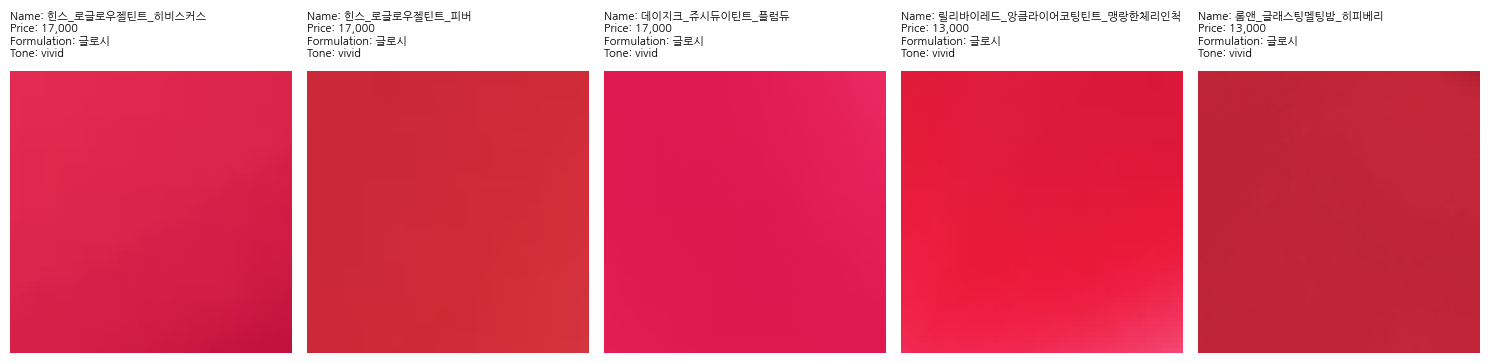






















입력한 사용자 정보가 저장되었습니다:
[{'user_color': '3CE_드롭글로우젤_RAWAPPLE', 'hydration_preference': '촉촉', 'Red202_preference': '네'}]


In [256]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.image as mpimg
import matplotlib.font_manager as fm
import asyncio
import ipywidgets as widgets
from IPython.display import display, clear_output


font_path = '/content/NanumGothic.ttf'  # Colab에서 파일을 업로드한 경로 확인

# 폰트 등록
fontprop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = fontprop.get_name()
plt.rcParams['axes.unicode_minus'] = False


# 사용자 데이터를 저장할 리스트
user_data_list = []

# 수분감 여부 옵션
hydration_options = ["촉촉", "매트", "상관없음"]

# 사용자 입력을 받을 위젯들
user_color_widget = widgets.Text(
    description='현재 사용하는 색상:',
    placeholder='브랜드_제품명_색상',
    style={'description_width': 'initial'}
)

hydration_widget = widgets.Dropdown(
    options=hydration_options,
    description='제형:',
    style={'description_width': 'initial'}
)

#적색
Red202_options = ["네","아니오", "상관없음"]

Red202_widget = widgets.Dropdown(
    options=Red202_options,
    description='적색202호 여부:',
    style={'description_width': 'initial'}
)

# 사용자 정보를 받는 함수
def get_user_input(button):
    user_data = {}

    # 색상 입력
    user_data["user_color"] = user_color_widget.value

    # 수분감 입력
    user_data["hydration_preference"] = hydration_widget.value

    # 적색202호 입력
    user_data["Red202_preference"] = Red202_widget.value

    # 입력된 사용자 정보 저장
    user_data_list.append(user_data)

    # 결과 출력
    print("\n입력한 사용자 정보가 저장되었습니다:")
    print(user_data_list)

# 버튼 위젯 생성
submit_button = widgets.Button(description="저장")
submit_button.on_click(get_user_input)

# 위젯들을 화면에 표시
display(user_color_widget, hydration_widget,Red202_widget, submit_button)
print()
print()
print()
print()



# 제품 추천 함수
def recommend_products(input_product, final_df, num_recommendations=5):
    try:
        final_df = calculate_rgb_similarity(input_product, final_df)
        final_df = calculate_formulation_tone_similarity(input_product, final_df)
        final_df = total_similarity(final_df)


        global product_names
        product_names = [input_product]

        recommendations = final_df[final_df['Normalized File Name'].str.lower() != input_product.lower()]
        recommended_products = recommendations[['Normalized File Name', 'Total Similarity']].head(num_recommendations)

        tones = []

        fig, axes = plt.subplots(1, num_recommendations, figsize=(15, 5))

        for idx, (index, row) in enumerate(recommended_products.iterrows()):
            product_name = os.path.splitext(row['Normalized File Name'])[0]
            normalized_file_name = row['Normalized File Name']
            product_names.append(product_name)

            price_row = final_df[final_df['Normalized File Name'] == normalized_file_name]['Price']
            price = price_row.iloc[0] if not price_row.empty else "Price not found"

            if not price_row.empty:
                price = price_row.iloc[0]
            else:
                price = "Price not found"

            formulation_row = final_df[final_df['Normalized File Name'] == normalized_file_name]['formulation']
            formulation = formulation_row.iloc[0] if not formulation_row.empty else "Formulation not found"
            if not formulation_row.empty:
                formulation = formulation_row.iloc[0]
            else:
                formulation = "Formulation not found"

            tone_row = final_df[final_df['Normalized File Name'] == normalized_file_name]['tone']
            tone = tone_row.iloc[0] if not tone_row.empty else "Tone not found"
            if not tone_row.empty:
                tone = tone_row.iloc[0]
            else:
                tone = "Tone not found"

            if tone != "Tone not found":
                tones.append(tone)

            # print()
            # print("Name:", product_name)
            # print("Price:", price)
            # print("Formulation:", formulation)
            # print("Tone:", tone)
            # print()
            image_path = f"/content/drive/MyDrive/oliveyoung_lip_color/{row['Normalized File Name']+'.png'}"
            img = mpimg.imread(image_path)
            # plt.figure(figsize=(1,1))
            axes[idx].imshow(img)
            axes[idx].axis('off')  # 축 제거
            axes[idx].set_title(
                f"Name: {product_name}\nPrice: {price}\nFormulation: {formulation}\nTone: {tone}",
                fontsize=8, loc="left", pad=10

            )

        plt.tight_layout()
        plt.show()
        plt.close('all')
        print()
        print()
        print()
        print()
        print()
        print()
        print()
        print()
        print()
        print()
        print()
        print()
        print()
        print()
        print()
        print()
        print()
        print()
        print()
        print()




        # return recommended_products


    except ValueError as e:
        print(e)

# 제품 추천
recommend_products(input_product, final_df)